In [25]:
!pip install hmmlearn

In [42]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
from scipy.stats import entropy

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [27]:
tickers = ['AAPL', 'MSFT', 'SPY']
data = yf.download(tickers, start="2020-01-01")['Close']
data.columns = ['A', 'B', 'C']

/tmp/ipykernel_410/4018829470.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2020-01-01")['Close']
[*********************100%***********************]  3 of 3 completed


In [28]:
assets = ['A','B','C']

for m in assets:
    data[f'return_{m}'] = np.log(data[m] / data[m].shift(1))

for m in assets:
    data[f'vol_{m}'] = data[f'return_{m}'].rolling(10).std()

data['corr_AB'] = data['return_A'].rolling(10).corr(data['return_B'])
data['corr_AC'] = data['return_A'].rolling(10).corr(data['return_C'])
data['corr_BC'] = data['return_B'].rolling(10).corr(data['return_C'])

data['cross_AB'] = data['return_A'] * data['return_B']
data['cross_AC'] = data['return_A'] * data['return_C']
data['cross_BC'] = data['return_B'] * data['return_C']

data = data.replace([np.inf, -np.inf], np.nan)

def rolling_entropy(series, window=20):
    ent = []

    for i in range(len(series)):
        if i < window:
            ent.append(np.nan)
        else:
            window_data = series[i-window:i].dropna()

            if len(window_data) == 0:
                ent.append(np.nan)
            else:
                hist, _ = np.histogram(window_data, bins=10, density=True)
                ent.append(entropy(hist + 1e-9))

    return np.array(ent)

data['entropy'] = rolling_entropy(data['return_A'])

data.dropna(inplace=True)

In [29]:
features = [
    'return_A','return_B','return_C',
    'vol_A','vol_B','vol_C',
    'corr_AB','corr_AC','corr_BC',
    'cross_AB','cross_AC','cross_BC'
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[features])

In [30]:
hmm = GaussianHMM(
    n_components=3,
    covariance_type="diag",
    n_iter=500,
    random_state=42
)
hmm.fit(X_scaled)

data['regime'] = hmm.predict(X_scaled)

means = pd.DataFrame(X_scaled, columns=features, index=data.index).groupby(data['regime']).mean()

vol_regime = means[['vol_A','vol_B','vol_C']].mean(axis=1)

sorted_regimes = vol_regime.sort_values().index

In [31]:
probs = hmm.predict_proba(X_scaled)

data['signal_hmm'] = (
    probs[:, sorted_regimes[0]] - probs[:, sorted_regimes[2]]
)

data['signal_hmm'] = data.apply(
    lambda x: x['signal_hmm'] if x['entropy'] < 2 else 0,
    axis=1
)

In [32]:
def create_sequences(X, y, time_steps=20):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, data['regime'].values)

split = int(len(X_seq)*0.8)

X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.6130 - loss: 0.8665 - val_accuracy: 0.6197 - val_loss: 0.7735
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6459 - loss: 0.7224 - val_accuracy: 0.6459 - val_loss: 0.7227
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6598 - loss: 0.7110 - val_accuracy: 0.6525 - val_loss: 0.7243
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6541 - loss: 0.7010 - val_accuracy: 0.6623 - val_loss: 0.7056
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6639 - loss: 0.7007 - val_accuracy: 0.6623 - val_loss: 0.7134
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6656 - loss: 0.6971 - val_accuracy: 0.6754 - val_loss: 0.6959
Epoch 7/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6730 - loss: 0.6730 - val_accuracy: 0.6590 - val_loss: 0.7041
Epoch 8/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6820 - loss: 0.6686 - val_accuracy: 0.6590 - val_loss: 0.

In [33]:
y_pred = model.predict(X_test)

prob_low = y_pred[:,0]
prob_high = y_pred[:,2]

ml_signal = prob_low - prob_high

test_index = data.index[-len(ml_signal):]

ml_data = pd.DataFrame(index=test_index)
ml_data['signal_lstm'] = ml_signal

ml_data['entropy'] = data.loc[test_index, 'entropy']
ml_data['signal_lstm'] = ml_data.apply(
    lambda x: x['signal_lstm'] if x['entropy'] < 2 else 0,
    axis=1
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [34]:
threshold = 0.1
data['volatility'] = data['return_A'].rolling(10).std()

data['pos_hmm'] = (data['signal_hmm'] / (data['volatility'] + 1e-6)).clip(-0.5,0.5)
data['pos_hmm'] = data['pos_hmm'].apply(lambda x: max(x, 0))  # <-- ini

ml_data['volatility'] = data.loc[test_index, 'volatility']
ml_data['pos_lstm'] = (ml_data['signal_lstm'] / (ml_data['volatility'] + 1e-6)).clip(-0.5,0.5)
ml_data['pos_lstm'] = ml_data['pos_lstm'].apply(lambda x: max(x, 0))  # <-- ini

In [35]:
data['market_return'] = data['return_A']
data['ret_hmm'] = data['pos_hmm'].shift(1) * data['market_return']
data['cum_hmm'] = (1 + data['ret_hmm']).cumprod()

vol_limit = data['volatility'].quantile(0.8)

data['signal_hmm'] = data.apply(
    lambda x: x['signal_hmm'] if x['volatility'] < vol_limit else 0,
    axis=1
)

ml_data['signal_lstm'] = ml_data.apply(
    lambda x: x['signal_lstm'] if x['volatility'] < vol_limit else 0,
    axis=1
)

ml_data['market_return'] = data.loc[test_index, 'return_A']
ml_data['ret_lstm'] = ml_data['pos_lstm'].shift(1) * ml_data['market_return']
ml_data['cum_lstm'] = (1 + ml_data['ret_lstm']).cumprod()

In [36]:
def sharpe_ratio(r):
    return r.mean() / r.std() * np.sqrt(252)

print("Sharpe HMM:", sharpe_ratio(data['ret_hmm'].dropna()))
print("Sharpe LSTM:", sharpe_ratio(ml_data['ret_lstm'].dropna()))

Sharpe HMM: 0.6136673778986645
Sharpe LSTM: 0.5392427343283243


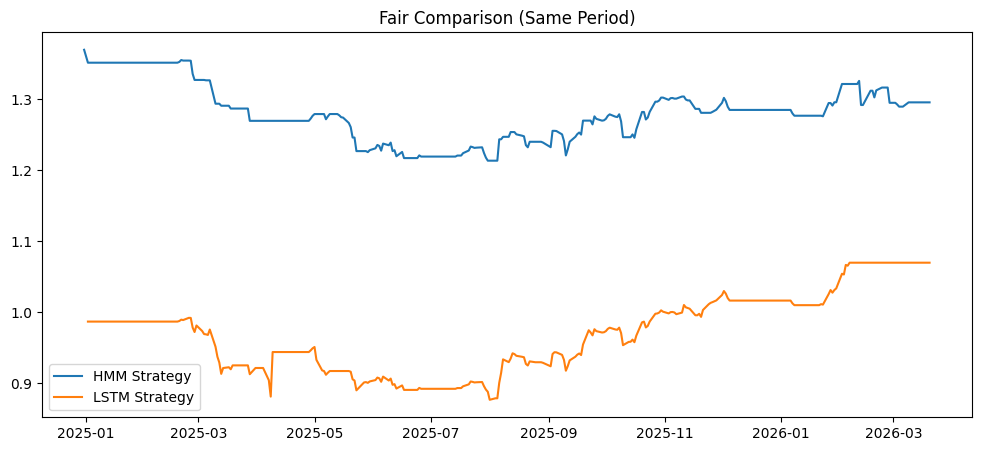

In [37]:
common_index = ml_data.index

plt.figure(figsize=(12,5))
plt.plot(data.loc[common_index, 'cum_hmm'], label='HMM Strategy')
plt.plot(ml_data['cum_lstm'], label='LSTM Strategy')
plt.legend()
plt.title("Fair Comparison (Same Period)")
plt.show()

Real Trading


=== EXTENDED EVALUATION ===
Sharpe HMM: -0.5363614945100461
Sharpe LSTM: 0.5392427343283243
Sharpe Buy & Hold: -0.030306959536355677
Max Drawdown HMM: -0.1141276781641682
Max Drawdown LSTM: -0.1164262067425792
Max Drawdown Buy & Hold: -0.32454955204157343


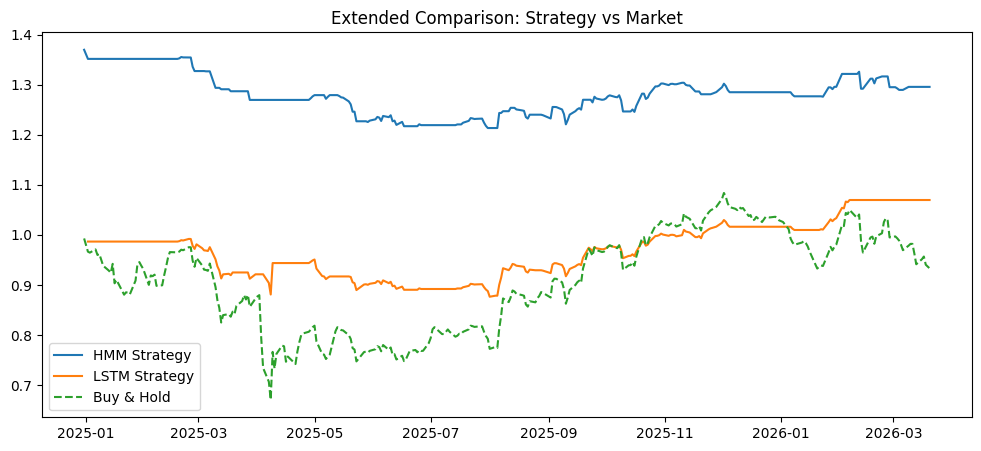

In [38]:
eval_index = ml_data.index

benchmark = data.loc[eval_index].copy()
benchmark['ret_bh'] = benchmark['return_A']
benchmark['cum_bh'] = (1 + benchmark['ret_bh']).cumprod()

print("\n=== EXTENDED EVALUATION ===")
print("Sharpe HMM:", sharpe_ratio(data.loc[eval_index, 'ret_hmm'].dropna()))
print("Sharpe LSTM:", sharpe_ratio(ml_data['ret_lstm'].dropna()))
print("Sharpe Buy & Hold:", sharpe_ratio(benchmark['ret_bh'].dropna()))

def max_drawdown(cum_returns):
    peak = cum_returns.cummax()
    drawdown = (cum_returns - peak) / peak
    return drawdown.min()

print("Max Drawdown HMM:", max_drawdown(data.loc[eval_index, 'cum_hmm']))
print("Max Drawdown LSTM:", max_drawdown(ml_data['cum_lstm']))
print("Max Drawdown Buy & Hold:", max_drawdown(benchmark['cum_bh']))

plt.figure(figsize=(12,5))

plt.plot(data.loc[eval_index, 'cum_hmm'], label='HMM Strategy')
plt.plot(ml_data['cum_lstm'], label='LSTM Strategy')
plt.plot(benchmark['cum_bh'], label='Buy & Hold', linestyle='--')

plt.legend()
plt.title("Extended Comparison: Strategy vs Market")
plt.show()

multi-period testing

In [39]:
periods = {
    "Bull Market (2020-2021)": ("2020-01-01", "2021-12-31"),
    "Bear Market (2022)": ("2022-01-01", "2022-12-31"),
    "Recovery (2023-Now)": ("2023-01-01", "2025-12-31")
}

results = []

for name, (start, end) in periods.items():

    period_index = data.loc[start:end].index.intersection(ml_data.index)

    if len(period_index) < 50:
        continue

    hmm_ret = data.loc[period_index, 'ret_hmm'].dropna()
    lstm_ret = ml_data.loc[period_index, 'ret_lstm'].dropna()
    bh_ret = data.loc[period_index, 'return_A'].dropna()

    sharpe_hmm = sharpe_ratio(hmm_ret)
    sharpe_lstm = sharpe_ratio(lstm_ret)
    sharpe_bh = sharpe_ratio(bh_ret)

    cum_hmm = (1 + hmm_ret).cumprod()
    cum_lstm = (1 + lstm_ret).cumprod()
    cum_bh = (1 + bh_ret).cumprod()

    dd_hmm = max_drawdown(cum_hmm)
    dd_lstm = max_drawdown(cum_lstm)
    dd_bh = max_drawdown(cum_bh)

    results.append({
        "Period": name,
        "Sharpe HMM": sharpe_hmm,
        "Sharpe LSTM": sharpe_lstm,
        "Sharpe BH": sharpe_bh,
        "DD HMM": dd_hmm,
        "DD LSTM": dd_lstm,
        "DD BH": dd_bh
    })

results_df = pd.DataFrame(results)

print("\n=== MULTI-PERIOD RESULTS ===")
print(results_df)


=== MULTI-PERIOD RESULTS ===
                Period  Sharpe HMM  Sharpe LSTM  Sharpe BH    DD HMM  \
0  Recovery (2023-Now)   -0.809239     0.192264   0.248447 -0.114128   

    DD LSTM    DD BH  
0 -0.116426 -0.32455  


semi-real trading simulation


=== REALISTIC BACKTEST ===
Sharpe HMM (real): -0.960652368166537
Sharpe LSTM (real): 0.4505824704140234
Sharpe Buy & Hold: -0.030306959536355677
Max DD HMM (real): -0.12808132641890557
Max DD LSTM (real): -0.12255756102357898
Max DD Buy & Hold: -0.32454955204157343


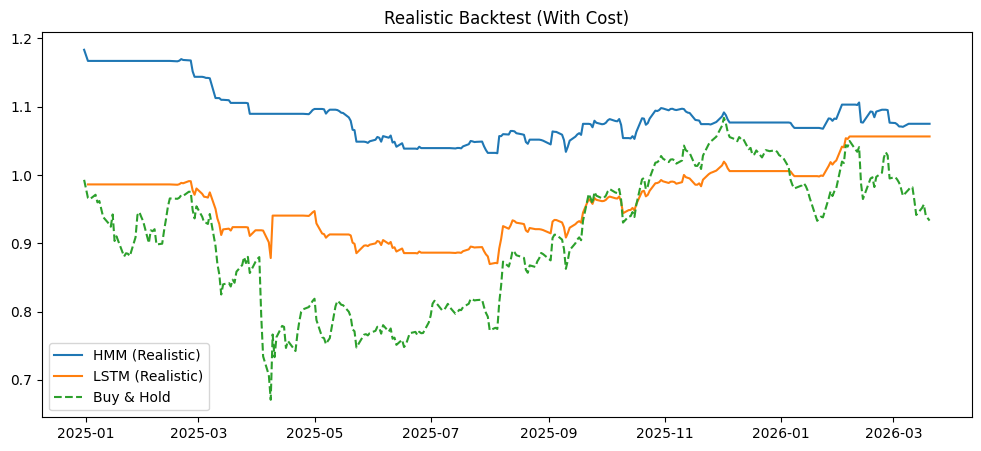

In [40]:
cost = 0.001

data['trade_hmm'] = data['pos_hmm'].diff().abs()
data['ret_hmm_real'] = (
    data['pos_hmm'].shift(1) * data['market_return']
    - cost * data['trade_hmm']
)

data['cum_hmm_real'] = (1 + data['ret_hmm_real']).cumprod()

ml_data['trade_lstm'] = ml_data['pos_lstm'].diff().abs()
ml_data['ret_lstm_real'] = (
    ml_data['pos_lstm'].shift(1) * ml_data['market_return']
    - cost * ml_data['trade_lstm']
)

ml_data['cum_lstm_real'] = (1 + ml_data['ret_lstm_real']).cumprod()

benchmark_real = data.loc[ml_data.index].copy()
benchmark_real['ret_bh'] = benchmark_real['return_A']
benchmark_real['cum_bh'] = (1 + benchmark_real['ret_bh']).cumprod()

print("\n=== REALISTIC BACKTEST ===")

print("Sharpe HMM (real):", sharpe_ratio(data.loc[ml_data.index, 'ret_hmm_real'].dropna()))
print("Sharpe LSTM (real):", sharpe_ratio(ml_data['ret_lstm_real'].dropna()))
print("Sharpe Buy & Hold:", sharpe_ratio(benchmark_real['ret_bh'].dropna()))

print("Max DD HMM (real):", max_drawdown(data.loc[ml_data.index, 'cum_hmm_real']))
print("Max DD LSTM (real):", max_drawdown(ml_data['cum_lstm_real']))
print("Max DD Buy & Hold:", max_drawdown(benchmark_real['cum_bh']))

plt.figure(figsize=(12,5))

plt.plot(data.loc[ml_data.index, 'cum_hmm_real'], label='HMM (Realistic)')
plt.plot(ml_data['cum_lstm_real'], label='LSTM (Realistic)')
plt.plot(benchmark_real['cum_bh'], label='Buy & Hold', linestyle='--')

plt.legend()
plt.title("Realistic Backtest (With Cost)")
plt.show()